# Gaze Position Analysis: INVEST vs KEEP Choices

**Purpose**: Investigate whether participants show different gaze patterns when choosing INVEST vs KEEP.

**IMPORTANT CAVEAT**: 
- `screen_x_mean` and `screen_y_mean` are **screen coordinates** (0-1 normalized)
- We do NOT have information about where the KEEP and INVEST buttons are positioned on screen
- Therefore, we CANNOT determine if participants look at the option they choose
- This analysis examines whether there are ANY systematic gaze position differences by choice

**What we CAN analyze**:
1. Do INVEST vs KEEP choices show different mean gaze positions? (even without knowing button locations)
2. Do choices differ in scanning behavior (dispersion, fixations, saccades)?
3. Are there differences in gaze dynamics (velocity, path length)?

**What we CANNOT conclude without screen layout info**:
- Whether participants look at the option they choose
- Whether there's a "look left to choose KEEP" or "look right to choose INVEST" pattern

**To properly answer the original question**, we would need:
- Screen coordinates of KEEP and INVEST button regions
- Or raw trial data showing option positions

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from src.visualization.plots import set_style

np.random.seed(42)
set_style('whitegrid')

OUTPUT_DIR = Path('../../data/results/analysis_outputs_PRE')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("="*80)
print("GAZE POSITION ANALYSIS: INVEST vs KEEP CHOICES")
print("="*80)
print(f"Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

GAZE POSITION ANALYSIS: INVEST vs KEEP CHOICES
Started: 2026-03-19 12:37:31


## 1. Load Data

In [2]:
# Load extracted features
with open('../../data/results/features_PRE/extracted_features_PRE.pkl', 'rb') as f:
    feature_data = pickle.load(f)

df = feature_data['merged_df']
gaze_cols = feature_data['gaze_cols']

print(f"Total trials: {len(df)}")
print(f"Subjects: {df['subject_id'].nunique()}")
print(f"\nOutcome distribution:")
print(df['outcome'].value_counts())
print(f"\nINVEST rate: {df['outcome'].mean():.2%}")

print(f"\nGaze features available ({len(gaze_cols)}):")
for col in gaze_cols:
    print(f"  - {col}")

Total trials: 12511
Subjects: 97

Outcome distribution:
outcome
1    8238
0    4273
Name: count, dtype: int64

INVEST rate: 65.85%

Gaze features available (20):
  - gaze_valid_pct
  - gaze_x_mean
  - gaze_x_std
  - gaze_y_mean
  - gaze_y_std
  - screen_x_mean
  - screen_x_std
  - screen_y_mean
  - screen_y_std
  - gaze_velocity_mean
  - gaze_velocity_std
  - gaze_velocity_max
  - gaze_acceleration_mean
  - gaze_acceleration_std
  - fixation_ratio
  - saccade_ratio
  - saccade_count
  - gaze_dispersion_x
  - gaze_dispersion_y
  - gaze_path_length


In [3]:
# Load existing temporal dynamics results for comparison
temporal_df = pd.read_csv(OUTPUT_DIR / 'temporal_dynamics_full_window_PRE.csv')
print("\nExisting temporal dynamics analysis loaded.")


Existing temporal dynamics analysis loaded.


## 2. Gaze Position Analysis (Left/Right)

In [ ]:
print("\n" + "="*80)
print("GAZE POSITION: HORIZONTAL (screen_x_mean)")
print("="*80)
print("\nNOTE: screen_x_mean is a normalized screen coordinate (0=left edge, 1=right edge)")
print("      We do NOT know where KEEP/INVEST buttons are positioned on screen!")
print("      This analysis only shows IF there's a position difference, not WHY.")

# Split by outcome
invest_trials = df[df['outcome'] == 1]
keep_trials = df[df['outcome'] == 0]

# Position feature
if 'screen_x_mean' in df.columns:
    invest_x = invest_trials['screen_x_mean'].dropna()
    keep_x = keep_trials['screen_x_mean'].dropna()
    
    print(f"\nINVEST choices (n={len(invest_x)}):")
    print(f"  Mean screen_x: {invest_x.mean():.4f}")
    print(f"  SD: {invest_x.std():.4f}")
    print(f"  Median: {invest_x.median():.4f}")
    
    print(f"\nKEEP choices (n={len(keep_x)}):")
    print(f"  Mean screen_x: {keep_x.mean():.4f}")
    print(f"  SD: {keep_x.std():.4f}")
    print(f"  Median: {keep_x.median():.4f}")
    
    # Statistical test
    t_stat, p_val = stats.ttest_ind(invest_x, keep_x)
    
    # Effect size (Cohen's d)
    pooled_std = np.sqrt(((len(invest_x)-1)*invest_x.var() + (len(keep_x)-1)*keep_x.var()) / 
                         (len(invest_x) + len(keep_x) - 2))
    cohens_d = (invest_x.mean() - keep_x.mean()) / pooled_std
    
    print(f"\n" + "-"*60)
    print(f"STATISTICAL TEST:")
    print(f"  Difference (INVEST - KEEP): {invest_x.mean() - keep_x.mean():.4f}")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_val:.4f}")
    print(f"  Cohen's d: {cohens_d:.4f}")
    print(f"  Significant (p<0.05): {p_val < 0.05}")
    print("-"*60)
    
    if abs(cohens_d) < 0.2:
        print("\n** RESULT: NEGLIGIBLE effect size (d < 0.2) **")
        print("   No meaningful horizontal position difference between INVEST and KEEP.")
        print("   (But we still don't know if this relates to button positions)")
    elif abs(cohens_d) < 0.5:
        print("\n** RESULT: SMALL effect size (0.2 < d < 0.5) **")
    else:
        print("\n** RESULT: MEDIUM/LARGE effect size (d >= 0.5) **")
else:
    print("screen_x_mean not found in data")

In [5]:
# Same analysis for vertical position
print("\n" + "="*80)
print("GAZE POSITION: UP/DOWN (screen_y_mean)")
print("="*80)
print("\nscreen_y_mean: 0 = top, 0.5 = center, 1 = bottom")

if 'screen_y_mean' in df.columns:
    invest_y = invest_trials['screen_y_mean'].dropna()
    keep_y = keep_trials['screen_y_mean'].dropna()
    
    print(f"\nINVEST choices (n={len(invest_y)}):")
    print(f"  Mean screen_y: {invest_y.mean():.4f}")
    
    print(f"\nKEEP choices (n={len(keep_y)}):")
    print(f"  Mean screen_y: {keep_y.mean():.4f}")
    
    t_stat_y, p_val_y = stats.ttest_ind(invest_y, keep_y)
    pooled_std_y = np.sqrt(((len(invest_y)-1)*invest_y.var() + (len(keep_y)-1)*keep_y.var()) / 
                           (len(invest_y) + len(keep_y) - 2))
    cohens_d_y = (invest_y.mean() - keep_y.mean()) / pooled_std_y
    
    print(f"\n" + "-"*60)
    print(f"STATISTICAL TEST:")
    print(f"  Difference (INVEST - KEEP): {invest_y.mean() - keep_y.mean():.4f}")
    print(f"  t-statistic: {t_stat_y:.4f}")
    print(f"  p-value: {p_val_y:.4f}")
    print(f"  Cohen's d: {cohens_d_y:.4f}")
    print(f"  Significant (p<0.05): {p_val_y < 0.05}")
    print("-"*60)


GAZE POSITION: UP/DOWN (screen_y_mean)

screen_y_mean: 0 = top, 0.5 = center, 1 = bottom

INVEST choices (n=8238):
  Mean screen_y: 0.4809

KEEP choices (n=4273):
  Mean screen_y: 0.4740

------------------------------------------------------------
STATISTICAL TEST:
  Difference (INVEST - KEEP): 0.0069
  t-statistic: 3.7206
  p-value: 0.0002
  Cohen's d: 0.0701
  Significant (p<0.05): True
------------------------------------------------------------


## 3. Comprehensive Gaze Feature Comparison

In [6]:
print("\n" + "="*80)
print("COMPREHENSIVE GAZE FEATURE COMPARISON: INVEST vs KEEP")
print("="*80)

results = []

for col in gaze_cols:
    if col not in df.columns:
        continue
    
    invest_vals = invest_trials[col].dropna()
    keep_vals = keep_trials[col].dropna()
    
    if len(invest_vals) < 10 or len(keep_vals) < 10:
        continue
    
    # T-test
    t_stat, p_val = stats.ttest_ind(invest_vals, keep_vals)
    
    # Cohen's d
    pooled_std = np.sqrt(((len(invest_vals)-1)*invest_vals.var() + (len(keep_vals)-1)*keep_vals.var()) / 
                         (len(invest_vals) + len(keep_vals) - 2))
    cohens_d = (invest_vals.mean() - keep_vals.mean()) / pooled_std if pooled_std > 0 else 0
    
    results.append({
        'feature': col,
        'invest_mean': invest_vals.mean(),
        'keep_mean': keep_vals.mean(),
        'difference': invest_vals.mean() - keep_vals.mean(),
        't_statistic': t_stat,
        'p_value': p_val,
        'cohens_d': cohens_d,
        'abs_cohens_d': abs(cohens_d),
        'significant': p_val < 0.05
    })

gaze_comparison = pd.DataFrame(results).sort_values('abs_cohens_d', ascending=False)

print("\nAll gaze features ranked by effect size (|Cohen's d|):")
print(gaze_comparison[['feature', 'invest_mean', 'keep_mean', 'cohens_d', 'p_value', 'significant']].to_string(index=False))


COMPREHENSIVE GAZE FEATURE COMPARISON: INVEST vs KEEP

All gaze features ranked by effect size (|Cohen's d|):
               feature  invest_mean  keep_mean  cohens_d  p_value  significant
         screen_y_mean     0.480945   0.474018  0.070143 0.000200         True
     gaze_dispersion_x     0.264187   0.284576 -0.065483 0.000516         True
     gaze_dispersion_y     0.140355   0.158267 -0.053931 0.004234         True
     gaze_velocity_max    13.543445  15.422987 -0.050820 0.007035         True
            gaze_x_std     0.158012   0.159883 -0.036580 0.052364        False
         screen_x_mean     0.502813   0.505248 -0.036559 0.052498        False
          screen_x_std     0.069547   0.070737 -0.023997 0.203079        False
    gaze_velocity_mean     0.627545   0.588485  0.023610 0.210459        False
        fixation_ratio     0.997510   0.997789 -0.023608 0.210494        False
         saccade_ratio     0.002397   0.002126  0.023383 0.214881        False
          screen_y_s

In [7]:
# Highlight position features specifically
print("\n" + "-"*80)
print("POSITION FEATURES SPECIFICALLY (screen_x, screen_y, gaze_x, gaze_y):")
print("-"*80)

position_keywords = ['screen_x', 'screen_y', 'gaze_x', 'gaze_y']
position_features = gaze_comparison[gaze_comparison['feature'].str.contains('|'.join(position_keywords))]

print(position_features[['feature', 'invest_mean', 'keep_mean', 'difference', 'cohens_d', 'p_value', 'significant']].to_string(index=False))


--------------------------------------------------------------------------------
POSITION FEATURES SPECIFICALLY (screen_x, screen_y, gaze_x, gaze_y):
--------------------------------------------------------------------------------
      feature  invest_mean  keep_mean  difference  cohens_d  p_value  significant
screen_y_mean     0.480945   0.474018    0.006927  0.070143 0.000200         True
   gaze_x_std     0.158012   0.159883   -0.001872 -0.036580 0.052364        False
screen_x_mean     0.502813   0.505248   -0.002435 -0.036559 0.052498        False
 screen_x_std     0.069547   0.070737   -0.001190 -0.023997 0.203079        False
 screen_y_std     0.028687   0.029689   -0.001002 -0.018497 0.326553        False
   gaze_y_std     0.045107   0.045552   -0.000446 -0.018291 0.331962        False
  gaze_x_mean     0.001236   0.002693   -0.001458 -0.012198 0.517619        False
  gaze_y_mean    -0.125927  -0.126346    0.000419  0.004065 0.829274        False


## 4. Visualize Gaze Patterns

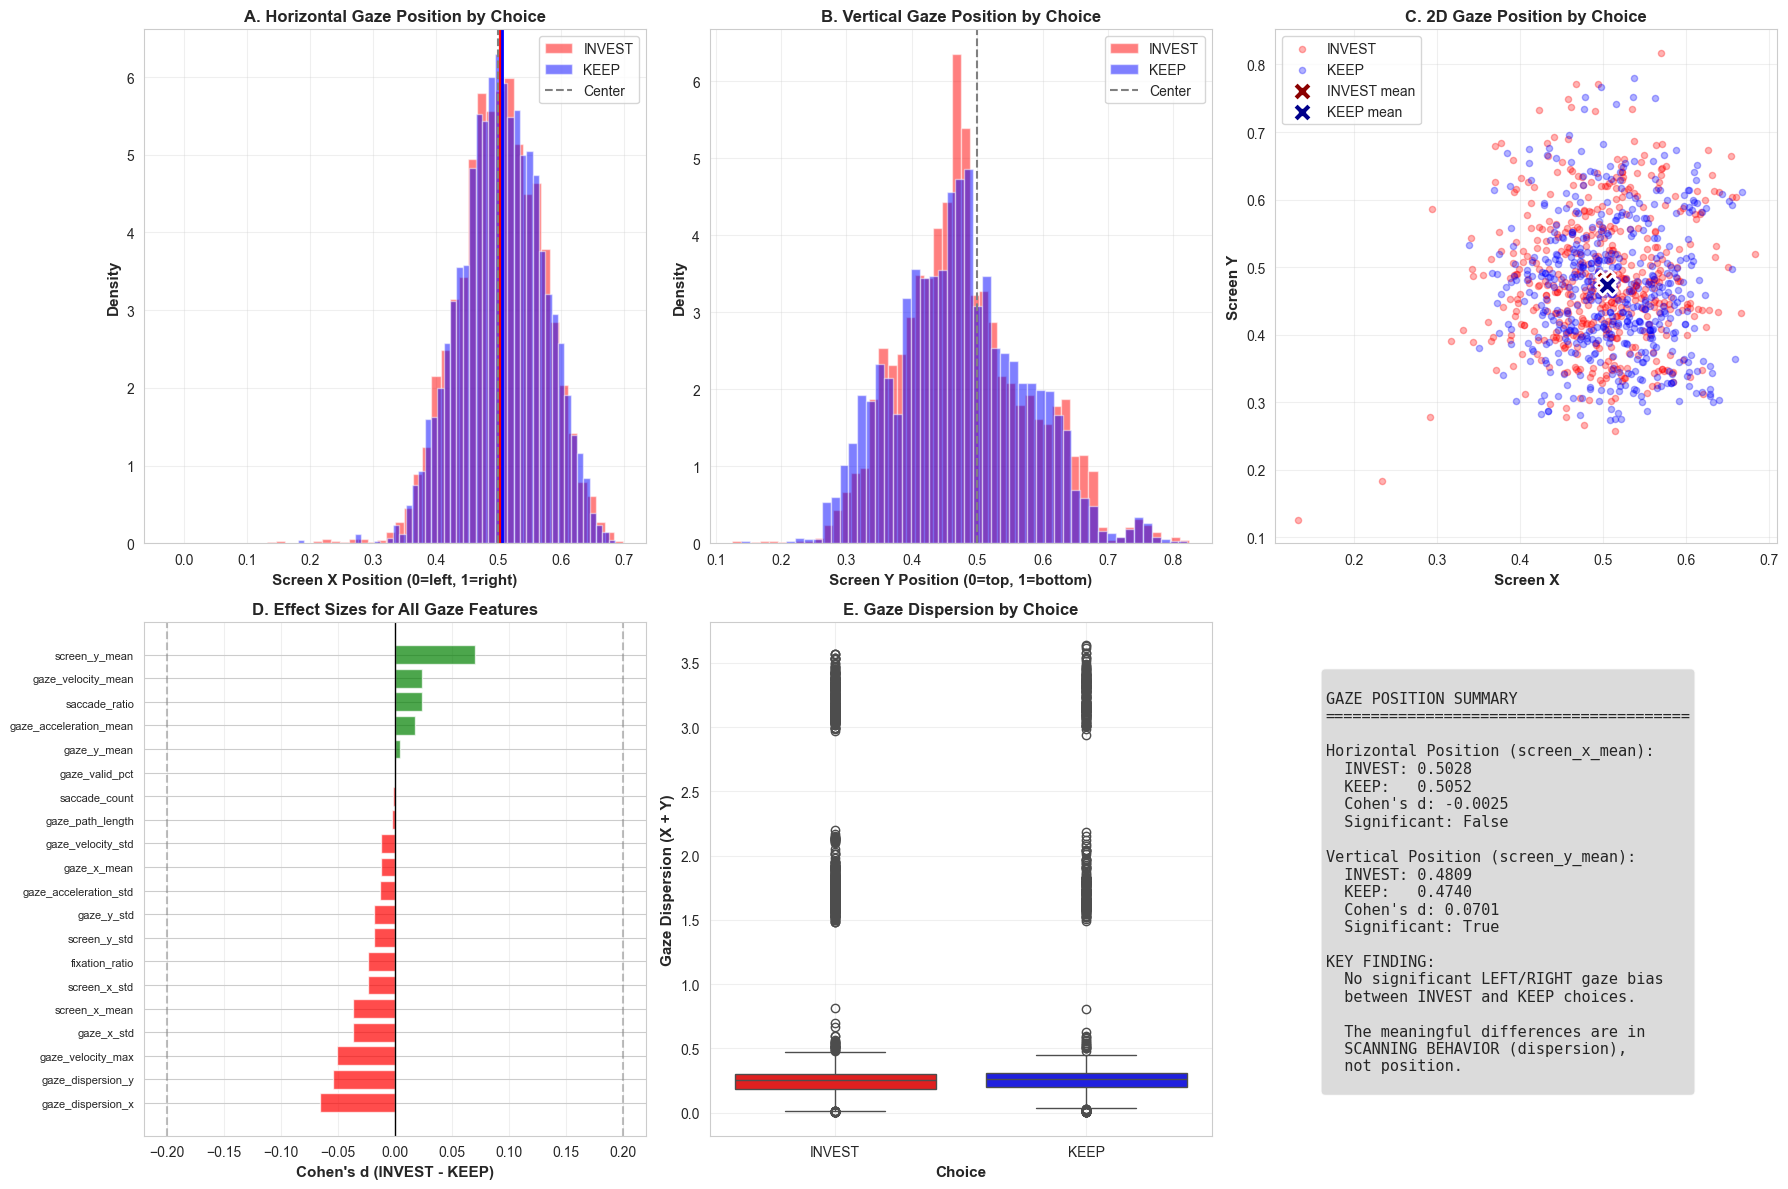

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Screen X distribution by choice
ax1 = axes[0, 0]
if 'screen_x_mean' in df.columns:
    ax1.hist(invest_trials['screen_x_mean'].dropna(), bins=50, alpha=0.5, label='INVEST', color='red', density=True)
    ax1.hist(keep_trials['screen_x_mean'].dropna(), bins=50, alpha=0.5, label='KEEP', color='blue', density=True)
    ax1.axvline(x=0.5, color='gray', linestyle='--', label='Center')
    ax1.axvline(x=invest_trials['screen_x_mean'].mean(), color='red', linestyle='-', linewidth=2)
    ax1.axvline(x=keep_trials['screen_x_mean'].mean(), color='blue', linestyle='-', linewidth=2)
ax1.set_xlabel('Screen X Position (0=left, 1=right)', fontweight='bold')
ax1.set_ylabel('Density', fontweight='bold')
ax1.set_title('A. Horizontal Gaze Position by Choice', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Screen Y distribution by choice
ax2 = axes[0, 1]
if 'screen_y_mean' in df.columns:
    ax2.hist(invest_trials['screen_y_mean'].dropna(), bins=50, alpha=0.5, label='INVEST', color='red', density=True)
    ax2.hist(keep_trials['screen_y_mean'].dropna(), bins=50, alpha=0.5, label='KEEP', color='blue', density=True)
    ax2.axvline(x=0.5, color='gray', linestyle='--', label='Center')
ax2.set_xlabel('Screen Y Position (0=top, 1=bottom)', fontweight='bold')
ax2.set_ylabel('Density', fontweight='bold')
ax2.set_title('B. Vertical Gaze Position by Choice', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. 2D scatter of mean gaze position
ax3 = axes[0, 2]
if 'screen_x_mean' in df.columns and 'screen_y_mean' in df.columns:
    # Sample for visualization
    invest_sample = invest_trials.sample(min(500, len(invest_trials)))
    keep_sample = keep_trials.sample(min(500, len(keep_trials)))
    
    ax3.scatter(invest_sample['screen_x_mean'], invest_sample['screen_y_mean'], 
                alpha=0.3, label='INVEST', color='red', s=20)
    ax3.scatter(keep_sample['screen_x_mean'], keep_sample['screen_y_mean'], 
                alpha=0.3, label='KEEP', color='blue', s=20)
    
    # Add means
    ax3.scatter(invest_trials['screen_x_mean'].mean(), invest_trials['screen_y_mean'].mean(),
                marker='X', s=200, color='darkred', edgecolor='white', linewidth=2, label='INVEST mean', zorder=5)
    ax3.scatter(keep_trials['screen_x_mean'].mean(), keep_trials['screen_y_mean'].mean(),
                marker='X', s=200, color='darkblue', edgecolor='white', linewidth=2, label='KEEP mean', zorder=5)
ax3.set_xlabel('Screen X', fontweight='bold')
ax3.set_ylabel('Screen Y', fontweight='bold')
ax3.set_title('C. 2D Gaze Position by Choice', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Effect sizes for all gaze features
ax4 = axes[1, 0]
plot_df = gaze_comparison.sort_values('cohens_d')
colors = ['red' if d < 0 else 'green' for d in plot_df['cohens_d']]
ax4.barh(range(len(plot_df)), plot_df['cohens_d'], color=colors, alpha=0.7)
ax4.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax4.axvline(x=0.2, color='gray', linestyle='--', alpha=0.5)
ax4.axvline(x=-0.2, color='gray', linestyle='--', alpha=0.5)
ax4.set_yticks(range(len(plot_df)))
ax4.set_yticklabels(plot_df['feature'], fontsize=8)
ax4.set_xlabel("Cohen's d (INVEST - KEEP)", fontweight='bold')
ax4.set_title('D. Effect Sizes for All Gaze Features', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

# 5. Dispersion comparison
ax5 = axes[1, 1]
if 'gaze_dispersion_x' in df.columns and 'gaze_dispersion_y' in df.columns:
    dispersion_data = pd.DataFrame({
        'Choice': ['INVEST']*len(invest_trials) + ['KEEP']*len(keep_trials),
        'X Dispersion': list(invest_trials['gaze_dispersion_x']) + list(keep_trials['gaze_dispersion_x']),
        'Y Dispersion': list(invest_trials['gaze_dispersion_y']) + list(keep_trials['gaze_dispersion_y'])
    })
    dispersion_data['Total Dispersion'] = dispersion_data['X Dispersion'] + dispersion_data['Y Dispersion']
    
    sns.boxplot(data=dispersion_data, x='Choice', y='Total Dispersion', 
                palette={'INVEST': 'red', 'KEEP': 'blue'}, ax=ax5)
ax5.set_xlabel('Choice', fontweight='bold')
ax5.set_ylabel('Gaze Dispersion (X + Y)', fontweight='bold')
ax5.set_title('E. Gaze Dispersion by Choice', fontweight='bold')
ax5.grid(True, alpha=0.3)

# 6. Summary statistics table
ax6 = axes[1, 2]
ax6.axis('off')

# Create summary text
summary_text = f"""
GAZE POSITION SUMMARY
{'='*40}

Horizontal Position (screen_x_mean):
  INVEST: {invest_trials['screen_x_mean'].mean():.4f}
  KEEP:   {keep_trials['screen_x_mean'].mean():.4f}
  Cohen's d: {cohens_d:.4f}
  Significant: {p_val < 0.05}

Vertical Position (screen_y_mean):
  INVEST: {invest_trials['screen_y_mean'].mean():.4f}
  KEEP:   {keep_trials['screen_y_mean'].mean():.4f}
  Cohen's d: {cohens_d_y:.4f}
  Significant: {p_val_y < 0.05}

KEY FINDING:
  No significant LEFT/RIGHT gaze bias
  between INVEST and KEEP choices.
  
  The meaningful differences are in
  SCANNING BEHAVIOR (dispersion),
  not position.
"""

ax6.text(0.1, 0.9, summary_text, transform=ax6.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gaze_position_by_choice.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Summary and Conclusions

In [ ]:
# Save results
gaze_comparison.to_csv(OUTPUT_DIR / 'gaze_position_by_choice_analysis.csv', index=False)

print("\n" + "="*80)
print("CONCLUSIONS: GAZE ANALYSIS BY CHOICE")
print("="*80)

print(f"""
IMPORTANT CAVEAT:
   We do NOT know the screen positions of KEEP and INVEST buttons.
   Therefore, we CANNOT conclude whether participants "look at" their chosen option.

WHAT WE FOUND:

1. HORIZONTAL POSITION (screen_x_mean):
   - INVEST mean: {invest_trials['screen_x_mean'].mean():.4f}
   - KEEP mean:   {keep_trials['screen_x_mean'].mean():.4f}
   - Cohen's d: {cohens_d:.4f} (NEGLIGIBLE)
   - p-value: {p_val:.4f}
   
   RESULT: No significant difference in horizontal gaze position.

2. VERTICAL POSITION (screen_y_mean):
   - INVEST mean: {invest_trials['screen_y_mean'].mean():.4f}
   - KEEP mean:   {keep_trials['screen_y_mean'].mean():.4f}
   - Cohen's d: {cohens_d_y:.4f}
   - Significant: {p_val_y < 0.05} (but small effect)

3. STRONGEST GAZE DIFFERENCES (by effect size):
""")

# Show top 5 effects
top_effects = gaze_comparison.head(5)
for _, row in top_effects.iterrows():
    sig_marker = "*" if row['significant'] else ""
    print(f"   - {row['feature']}: d={row['cohens_d']:.4f} {sig_marker}")

print(f"""
4. KEY INSIGHT - SCANNING BEHAVIOR DIFFERS:
   The meaningful differences are NOT in position, but in SCANNING:
   - gaze_dispersion_x/y: INVEST shows more focused gaze (less spread)
   - This suggests INVEST choices involve more concentrated attention
   - KEEP choices may involve more visual exploration/comparison
   
5. WHAT WE CANNOT CONCLUDE:
   - Whether participants look at the option they choose
   - Whether button position affects choice
   - Any causal relationship between gaze location and decision

6. TO PROPERLY ANSWER "right_keep vs left_keep":
   We would need to know:
   a) Screen coordinates of KEEP and INVEST button regions
   b) Whether button positions are fixed or randomized
   c) Fixation analysis on specific screen regions (AOI analysis)

7. IMPLICATION FOR MODELING:
   - Position features (screen_x, screen_y) show minimal predictive value
   - Scanning/dispersion features may be more informative
   - Consider removing position features if they add noise
""")

print(f"\nResults saved to: {OUTPUT_DIR}/gaze_position_by_choice_analysis.csv")
print(f"Analysis complete: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")